# 📊 Cambrian Hedge Fund vs. Bitcoin (BTC) & Ethereum (ETH) Regression Analysis

This notebook performs a multiple linear regression analysis of the monthly returns of **Cambrian Hedge Fund** against the returns of **Bitcoin (BTC)** and **Ethereum (ETH)** to understand systematic crypto exposure.

## 1. Import Libraries and Load Cambrian Returns
We load the monthly returns for Cambrian Hedge Fund from `./data/hf_returns/cambrian.csv`.

In [10]:
import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Set aesthetic style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load Cambrian returns
cambrian = pd.read_csv('data/hf_returns/cambrian.csv')
cambrian['Date'] = pd.to_datetime(cambrian['Date'])
cambrian['Period'] = cambrian['Date'].dt.to_period('M')
cambrian.set_index('Period', inplace=True)

print("Cambrian Returns (First 5 Rows):")
print(cambrian.head())
print(f"\nTotal observations: {len(cambrian)} months")

Cambrian Returns (First 5 Rows):
              Date  Return
Period                    
2018-11 2018-11-01   0.024
2018-12 2018-12-01   0.028
2019-01 2019-01-01   0.000
2019-02 2019-02-01   0.110
2019-03 2019-03-01   0.029

Total observations: 90 months


## 2. Download Bitcoin (BTC) and Ethereum (ETH) Data
We download daily Close prices for both BTC-USD and ETH-USD from Yahoo Finance, resample to monthly levels, and calculate returns.

In [11]:
# Define date range matching Cambrian's start
start_date = '2018-10-01'
end_date = '2026-05-01'

print("Downloading BTC-USD daily data...")
btc_raw = yf.download('BTC-USD', start=start_date, end=end_date)

print("Downloading ETH-USD daily data...")
eth_raw = yf.download('ETH-USD', start=start_date, end=end_date)

# Extract Close prices
btc_close = btc_raw['Close'] if 'Close' in btc_raw.columns else btc_raw[('Close', 'BTC-USD')]
eth_close = eth_raw['Close'] if 'Close' in eth_raw.columns else eth_raw[('Close', 'ETH-USD')]

# Resample to monthly and compute percentage returns
try:
    btc_monthly = btc_close.resample('ME').last()
    eth_monthly = eth_close.resample('ME').last()
except ValueError:
    btc_monthly = btc_close.resample('M').last()
    eth_monthly = eth_close.resample('M').last()

btc_returns = btc_monthly.pct_change().dropna()
btc_returns.index = btc_returns.index.to_period('M')
btc_returns.name = 'BTC_Return'

eth_returns = eth_monthly.pct_change().dropna()
eth_returns.index = eth_returns.index.to_period('M')
eth_returns.name = 'ETH_Return'

print("\nBitcoin Monthly Returns (First 5 Rows):")
print(btc_returns.head())
print("\nEthereum Monthly Returns (First 5 Rows):")
print(eth_returns.head())

/var/folders/mc/qf75k40s6ns_nr8c35wdmp400000gn/T/ipykernel_27072/2889025805.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc_raw = yf.download('BTC-USD', start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/var/folders/mc/qf75k40s6ns_nr8c35wdmp400000gn/T/ipykernel_27072/2889025805.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  eth_raw = yf.download('ETH-USD', start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Bitcoin Monthly Returns (First 5 Rows):
Ticker    BTC-USD
Date             
2018-11 -0.364116
2018-12 -0.068347
2019-01 -0.076124
2019-02  0.114811
2019-03  0.065015

Ethereum Monthly Returns (First 5 Rows):
Ticker    ETH-USD
Date             
2018-11 -0.426635
2018-12  0.178462
2019-01 -0.197253
2019-02  0.277274
2019-03  0.034866


## 3. Merge and Align Returns
We merge Cambrian's returns with BTC and ETH returns.

In [12]:
# Merge returns
merged_df = pd.merge(cambrian[['Return']], btc_returns, left_index=True, right_index=True, how='inner')
merged_df = pd.merge(merged_df, eth_returns, left_index=True, right_index=True, how='inner')
merged_df.rename(columns={'Return': 'Cambrian_Return'}, inplace=True)

print(f"Merged Dataset (Total {len(merged_df)} aligned observations):")
print(merged_df.head())

Merged Dataset (Total 90 aligned observations):
         Cambrian_Return   BTC-USD   ETH-USD
Period                                      
2018-11            0.024 -0.364116 -0.426635
2018-12            0.028 -0.068347  0.178462
2019-01            0.000 -0.076124 -0.197253
2019-02            0.110  0.114811  0.277274
2019-03            0.029  0.065015  0.034866


## 4. Multiple Linear Regression
We regress Cambrian monthly returns on both Bitcoin and Ethereum monthly returns:

$$R_{\text{Cambrian}, t} = \alpha + \beta_1 \cdot R_{\text{BTC}, t} + \beta_2 \cdot R_{\text{ETH}, t} + \epsilon_t$$

In [ ]:
X = sm.add_constant(merged_df[['BTC-USD', 'ETH-USD']])
y = merged_df['Cambrian_Return']

# Fit OLS model
model = sm.OLS(y, X).fit()

# Summary of results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        Cambrian_Return   R-squared:                       0.611
Model:                            OLS   Adj. R-squared:                  0.602
Method:                 Least Squares   F-statistic:                     68.24
Date:                Thu, 21 May 2026   Prob (F-statistic):           1.50e-18
Time:                        23:47:55   Log-Likelihood:                 121.23
No. Observations:                  90   AIC:                            -236.5
Df Residuals:                      87   BIC:                            -229.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0094      0.007      1.349      0.1

## 5. Visualizations
We plot the actual vs. predicted returns scatter plot and compare the cumulative growth of $1 across all three assets.

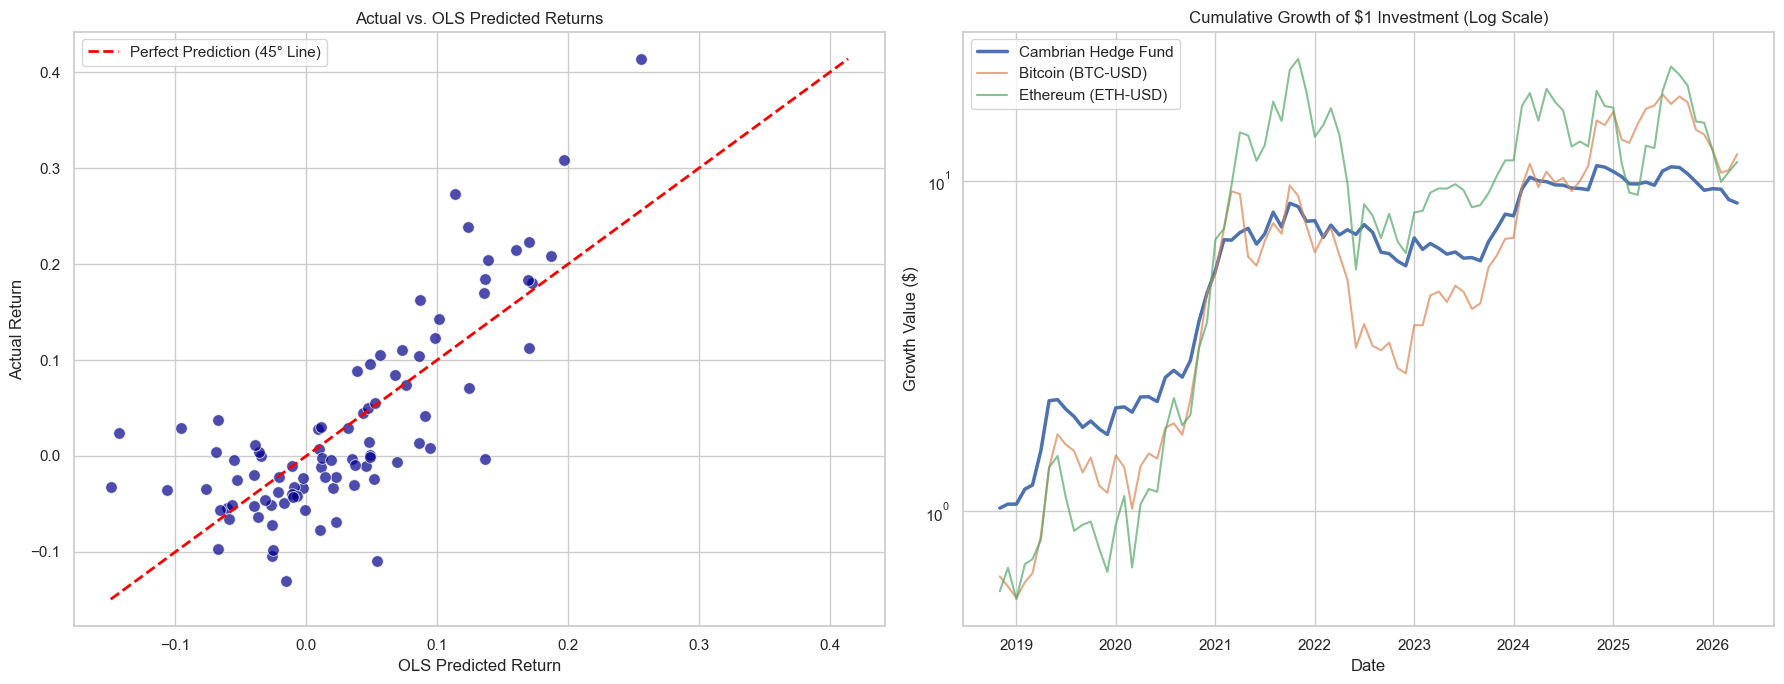

In [15]:
# Add OLS predicted returns
merged_df['Predicted_Return'] = model.predict(X)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Actual vs. Predicted Returns Scatter Plot
sns.scatterplot(
    x='Predicted_Return', 
    y='Cambrian_Return', 
    data=merged_df, 
    ax=axes[0], 
    color='darkblue', 
    s=70, 
    alpha=0.7
)
min_val = min(merged_df['Cambrian_Return'].min(), merged_df['Predicted_Return'].min())
max_val = max(merged_df['Cambrian_Return'].max(), merged_df['Predicted_Return'].max())
axes[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction (45° Line)')
axes[0].set_title('Actual vs. OLS Predicted Returns')
axes[0].set_xlabel('OLS Predicted Return')
axes[0].set_ylabel('Actual Return')
axes[0].legend()

# 2. Cumulative Returns Comparison (Log Scale)
cambrian_cum = (1 + merged_df['Cambrian_Return']).cumprod()
btc_cum = (1 + merged_df['BTC-USD']).cumprod()
eth_cum = (1 + merged_df['ETH-USD']).cumprod()

plot_dates = merged_df.index.to_timestamp()
axes[1].plot(plot_dates, cambrian_cum, label='Cambrian Hedge Fund', linewidth=2.5)
axes[1].plot(plot_dates, btc_cum, label='Bitcoin (BTC-USD)', alpha=0.7)
axes[1].plot(plot_dates, eth_cum, label='Ethereum (ETH-USD)', alpha=0.7)
axes[1].set_title('Cumulative Growth of $1 Investment (Log Scale)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Growth Value ($)')
axes[1].set_yscale('log')
axes[1].legend()

plt.tight_layout()
plt.show()

In [22]:
merged_df[merged_df['BTC-USD'] > 0].corr()

,Cambrian_Return,BTC-USD,ETH-USD,Predicted_Return
Cambrian_Return,1.000000,0.816642,0.637039,0.842436
BTC-USD,0.816642,1.000000,0.559629,0.943262
ETH-USD,0.637039,0.559629,1.000000,0.803061
Predicted_Return,0.842436,0.943262,0.803061,1.000000
